# Detector × recognizer grid search (15 scenes)

Sweep **MTCNN** and **RetinaFace** against **GhostFaceNet**, **Facenet512**, and **ArcFace**. For each pair, search a small **cosine-distance vote threshold** grid (same semantics as `people_identification_voting_simple.ipynb`: votes if dist ≤ T, `MIN_VOTES` floor, winner = **min mean** distance over voting rows).

**Metric:** mean score = average of per-scene `0.5*precision + 0.5*recall` (NaNs treated as 0), matching the token-based set evaluation in the simple notebook. **Tie-break:** higher `token_ok` rate (strict set match).

**Runtime:** builds the gallery **once per recognizer** (3×), then runs 2 detectors × thresholds × 15 scenes × faces — expect **many minutes** on CPU.

**Requires:** `open_data_set/photos_all_faces` and `open_data_set/photos_all`, project `.venv` with DeepFace + `retina-face`.


In [1]:
# Imports & quiet Keras bars
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

from pathlib import Path
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from deepface import DeepFace
from tqdm.auto import tqdm

tf.keras.utils.disable_interactive_logging()
warnings.filterwarnings("ignore", category=UserWarning)
print("OK: imports")


/Users/shamiul/Documents/GitHub/AI-Computer-Vision-Project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


OK: imports


In [2]:
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "open_data_set"
GALLERY_DIR = DATASET_ROOT / "photos_all_faces"
SCENES_DIR = DATASET_ROOT / "photos_all"

# --- sweep config ---
DETECTORS = ["mtcnn", "retinaface"]
MODELS = ["GhostFaceNet", "Facenet512", "ArcFace"]
MIN_VOTES = 5
NUM_SCENES = 15
# Cosine-style distance (1 - cos sim); tune per model family
THRESHOLD_GRID = [0.08, 0.10, 0.12, 0.15, 0.18, 0.22, 0.28, 0.35, 0.45, 0.55]


def list_images(folder: Path):
    out = []
    if not folder.is_dir():
        return out
    for pat in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
        out.extend(folder.glob(pat))
    return sorted(out)


def infer_identity(path: Path) -> str:
    return path.stem.split("_")[0].upper()


def token_to_expected_ids(token: str):
    return set(list(token.upper()))


def cosine_distance(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> float:
    a_norm = np.linalg.norm(a) + eps
    b_norm = np.linalg.norm(b) + eps
    return float(1.0 - np.dot(a, b) / (a_norm * b_norm))


scene_paths_all = list_images(SCENES_DIR)
SCENE_SUBSET = scene_paths_all[:NUM_SCENES]
print("Gallery:", GALLERY_DIR)
print("Scenes (first %d):" % NUM_SCENES, len(SCENE_SUBSET), "of", len(scene_paths_all))


Gallery: /Users/shamiul/Documents/GitHub/AI-Computer-Vision-Project/open_data_set/photos_all_faces
Scenes (first 15): 15 of 620


In [3]:
# Build gallery table (paths) + embeddings for one recognizer


def build_gallery_df(model_name: str) -> pd.DataFrame:
    paths = list_images(GALLERY_DIR)
    if not paths:
        raise FileNotFoundError(GALLERY_DIR)
    rows = [{"path": str(p.resolve()), "identity": infer_identity(p)} for p in paths]
    gallery_paths = pd.DataFrame(rows)
    embs = []
    for _, row in tqdm(gallery_paths.iterrows(), total=len(gallery_paths), desc=f"Gallery {model_name}"):
        try:
            rep = DeepFace.represent(
                img_path=row["path"],
                model_name=model_name,
                detector_backend="skip",
                enforce_detection=False,
            )
            embs.append(np.array(rep[0]["embedding"], dtype=np.float32))
        except Exception:
            embs.append(None)
    return gallery_paths.assign(embedding=embs).dropna(subset=["embedding"]).reset_index(drop=True)


# cache: model_name -> gallery_df
GALLERY_CACHE = {}
for m in MODELS:
    GALLERY_CACHE[m] = build_gallery_df(m)
    print(m, "rows:", len(GALLERY_CACHE[m]))


Gallery GhostFaceNet: 100%|██████████| 1364/1364 [01:45<00:00, 12.90it/s]


GhostFaceNet rows: 1364


Gallery Facenet512: 100%|██████████| 1364/1364 [03:51<00:00,  5.88it/s]


Facenet512 rows: 1364


Gallery ArcFace: 100%|██████████| 1364/1364 [02:35<00:00,  8.78it/s]

ArcFace rows: 1364


In [4]:
# Matcher + scene pipeline (threshold passed explicitly)


def match_gallery(gallery_df: pd.DataFrame, probe_emb: np.ndarray, match_threshold: float, min_votes: int) -> dict:
    dists = gallery_df["embedding"].apply(lambda e: cosine_distance(probe_emb, e))
    g = gallery_df.assign(_d=dists)
    under = g["_d"] <= match_threshold
    all_ids_sorted = sorted(gallery_df["identity"].unique())

    def _empty_votes():
        return {i: 0 for i in all_ids_sorted}

    def _diag_row(votes_by_id: dict):
        j = int(dists.idxmin())
        return {
            "predicted_id": None,
            "accepted": False,
            "vote_count": 0,
            "nearest_distance": float(dists.loc[j]),
            "min_dist_global": float(dists.min()),
            "votes_by_id": votes_by_id,
        }

    if under.sum() == 0:
        return _diag_row(_empty_votes())

    vc = g.loc[under].groupby("identity").size()
    votes_by_id = {i: int(vc.get(i, 0)) for i in all_ids_sorted}
    candidates = vc[vc >= min_votes]
    if len(candidates) == 0:
        out = _diag_row(votes_by_id)
        out["vote_count"] = int(vc.max()) if len(vc) else 0
        return out

    def _mean_vote_dist(ident):
        return float(g.loc[under & (g["identity"] == ident), "_d"].mean())

    def _min_vote_dist(ident):
        return float(g.loc[under & (g["identity"] == ident), "_d"].min())

    cand_ids = list(candidates.index)
    pred_id = min(
        cand_ids,
        key=lambda ident: (
            _mean_vote_dist(ident),
            _min_vote_dist(ident),
            -int(candidates[ident]),
        ),
    )
    sub_vote = g.loc[under & (g["identity"] == pred_id)]
    return {
        "predicted_id": pred_id,
        "accepted": True,
        "vote_count": int(candidates[pred_id]),
        "nearest_distance": float(sub_vote["_d"].mean()),
        "min_dist_global": float(dists.min()),
        "votes_by_id": votes_by_id,
    }


def item_to_box_and_crop(item, scene_bgr, h0, w0):
    a = item["facial_area"]
    x = max(0, min(int(a["x"]), w0 - 1))
    y = max(0, min(int(a["y"]), h0 - 1))
    w = max(1, min(int(a["w"]), w0 - x))
    h = max(1, min(int(a["h"]), h0 - y))
    if w < 10 or h < 10:
        return None
    b = {"x": x, "y": y, "w": w, "h": h}
    face_arr = item.get("face")
    if face_arr is not None:
        fa = np.asarray(face_arr)
        if fa.dtype != np.uint8:
            fa = np.clip(fa * 255.0, 0, 255).astype(np.uint8)
        crop_rgb = fa[:, :, :3]
    else:
        crop_bgr = scene_bgr[b["y"] : b["y"] + b["h"], b["x"] : b["x"] + b["w"]]
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    return b, crop_rgb


def scene_to_metrics(scene_bgr, gallery_df, detector_backend: str, model_name: str, match_threshold: float):
    h0, w0 = scene_bgr.shape[:2]
    try:
        raw_faces = DeepFace.extract_faces(
            img_path=scene_bgr,
            detector_backend=detector_backend,
            enforce_detection=True,
            align=True,
        )
    except Exception:
        raw_faces = []
    items_ok = []
    for item in raw_faces:
        pair = item_to_box_and_crop(item, scene_bgr, h0, w0)
        if pair is not None:
            items_ok.append(pair)
    predicted_list = []
    for _, crop_rgb in items_ok:
        rep = DeepFace.represent(
            img_path=crop_rgb,
            model_name=model_name,
            detector_backend="skip",
            enforce_detection=False,
        )
        emb = np.array(rep[0]["embedding"], dtype=np.float32)
        m = match_gallery(gallery_df, emb, match_threshold, MIN_VOTES)
        pred_id = m["predicted_id"] if m["accepted"] else None
        if pred_id is not None:
            predicted_list.append(pred_id)
    predicted_set = set(predicted_list)
    return predicted_set, len(items_ok)


def scene_path_score(scene_path: Path, gallery_df, detector_backend: str, model_name: str, match_threshold: float):
    token = scene_path.stem.split("_")[0].upper()
    expected_ids = token_to_expected_ids(token)
    img = cv2.imread(str(scene_path))
    if img is None:
        return dict(precision=np.nan, recall=np.nan, f1=np.nan, token_ok=False, n_faces=0)
    pred_set, n_faces = scene_to_metrics(img, gallery_df, detector_backend, model_name, match_threshold)
    tp = len(pred_set & expected_ids)
    fp = len(pred_set - expected_ids)
    fn = len(expected_ids - pred_set)
    prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    rec = tp / len(expected_ids) if len(expected_ids) > 0 else np.nan
    if prec == prec and rec == rec and (prec + rec) > 0:
        f1 = 2 * prec * rec / (prec + rec)
    else:
        f1 = np.nan
    token_ok = fp == 0 and fn == 0 and len(expected_ids) > 0
    return dict(
        precision=prec,
        recall=rec,
        f1=f1,
        token_ok=token_ok,
        n_faces=n_faces,
        tp=tp,
        fp=fp,
        fn=fn,
    )


print("match_gallery + scene_to_metrics ready.")


match_gallery + scene_to_metrics ready.


In [5]:
# Grid search
rows = []
for model_name in MODELS:
    gdf = GALLERY_CACHE[model_name]
    for det in DETECTORS:
        for thr in tqdm(THRESHOLD_GRID, desc=f"{model_name}|{det} thresholds"):
            prs, rcs, f1s, toks = [], [], [], []
            for sp in SCENE_SUBSET:
                m = scene_path_score(Path(sp), gdf, det, model_name, float(thr))
                prs.append(0.0 if m["precision"] != m["precision"] else float(m["precision"]))
                rcs.append(0.0 if m["recall"] != m["recall"] else float(m["recall"]))
                f1s.append(0.0 if m["f1"] != m["f1"] else float(m["f1"]))
                toks.append(bool(m["token_ok"]))
            mean_pr = float(np.mean(prs))
            mean_rc = float(np.mean(rcs))
            mean_f1 = float(np.mean(f1s))
            score = 0.5 * mean_pr + 0.5 * mean_rc
            rows.append(
                dict(
                    detector=det,
                    model=model_name,
                    threshold=thr,
                    mean_precision=mean_pr,
                    mean_recall=mean_rc,
                    mean_f1=mean_f1,
                    score=score,
                    token_ok_rate=sum(toks) / len(SCENE_SUBSET),
                )
            )

results_df = pd.DataFrame(rows)
_csv = PROJECT_ROOT / "detector_recognizer_grid_results.csv"
results_df.to_csv(_csv, index=False)
print("Done. Rows:", len(results_df), "| wrote", _csv)
results_df.sort_values(["score", "token_ok_rate", "mean_f1"], ascending=False).head(12)


GhostFaceNet|mtcnn thresholds: 100%|██████████| 10/10 [12:07<00:00, 72.71s/it]
GhostFaceNet|retinaface thresholds: 100%|██████████| 10/10 [00:26<00:00,  2.70s/it]
Facenet512|mtcnn thresholds: 100%|██████████| 10/10 [24:21<00:00, 146.20s/it]
Facenet512|retinaface thresholds: 100%|██████████| 10/10 [00:28<00:00,  2.84s/it]
ArcFace|mtcnn thresholds: 100%|██████████| 10/10 [12:26<00:00, 74.66s/it]
ArcFace|retinaface thresholds: 100%|██████████| 10/10 [00:27<00:00,  2.77s/it]

Done. Rows: 60 | wrote /Users/shamiul/Documents/GitHub/AI-Computer-Vision-Project/detector_recognizer_grid_results.csv


,detector,model,threshold,mean_precision,mean_recall,mean_f1,score,token_ok_rate
29,mtcnn,Facenet512,0.55,0.366667,0.266667,0.300000,0.316667,0.133333
28,mtcnn,Facenet512,0.45,0.333333,0.200000,0.244444,0.266667,0.066667
27,mtcnn,Facenet512,0.35,0.200000,0.133333,0.155556,0.166667,0.066667
26,mtcnn,Facenet512,0.28,0.133333,0.100000,0.111111,0.116667,0.066667
40,mtcnn,ArcFace,0.08,0.066667,0.033333,0.044444,0.050000,0.000000
41,mtcnn,ArcFace,0.10,0.066667,0.033333,0.044444,0.050000,0.000000
42,mtcnn,ArcFace,0.12,0.066667,0.033333,0.044444,0.050000,0.000000
48,mtcnn,ArcFace,0.45,0.066667,0.033333,0.044444,0.050000,0.000000
49,mtcnn,ArcFace,0.55,0.066667,0.033333,0.044444,0.050000,0.000000
44,mtcnn,ArcFace,0.18,0.033333,0.033333,0.033333,0.033333,0.000000


In [6]:
# Best row per (detector, model) and overall winner
idx = results_df.groupby(["detector", "model"])["score"].idxmax()
best_per_pair = results_df.loc[idx].reset_index(drop=True)
overall_i = int(results_df["score"].values.argmax())
best_overall = results_df.iloc[overall_i]
print("=== Best per detector × model ===")
print(best_per_pair[["detector", "model", "threshold", "score", "mean_f1", "token_ok_rate"]].to_string(index=False))
print("\n=== Overall best single setting ===")
print(best_overall.to_string())

# Table for plotting: one bar per (detector, model) using each pair's best threshold score
plot_df = best_per_pair.copy()
plot_df["label"] = plot_df["detector"] + "\n" + plot_df["model"]


=== Best per detector × model ===
  detector        model  threshold    score  mean_f1  token_ok_rate
     mtcnn      ArcFace       0.08 0.050000 0.044444       0.000000
     mtcnn   Facenet512       0.55 0.316667 0.300000       0.133333
     mtcnn GhostFaceNet       0.08 0.000000 0.000000       0.000000
retinaface      ArcFace       0.08 0.000000 0.000000       0.000000
retinaface   Facenet512       0.08 0.000000 0.000000       0.000000
retinaface GhostFaceNet       0.08 0.000000 0.000000       0.000000

=== Overall best single setting ===
detector               mtcnn
model             Facenet512
threshold               0.55
mean_precision      0.366667
mean_recall         0.266667
mean_f1                  0.3
score               0.316667
token_ok_rate       0.133333


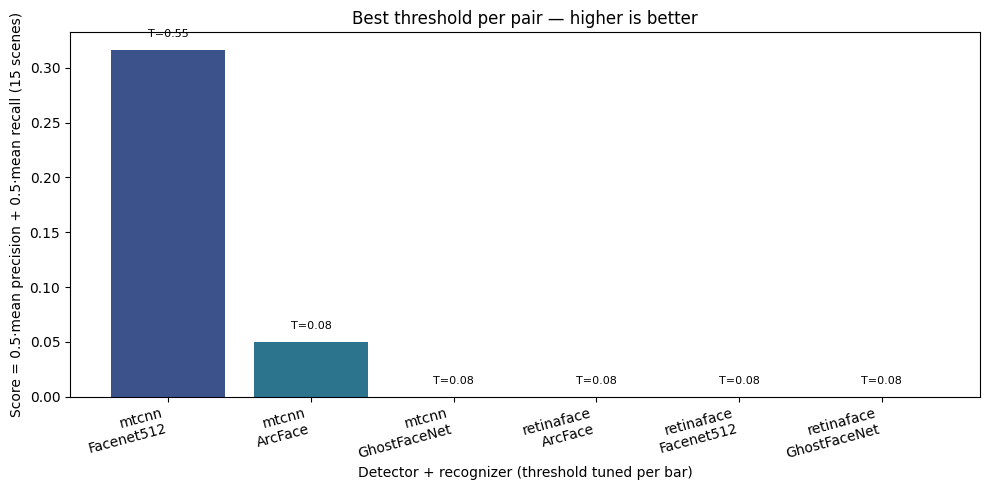


Winner: mtcnn + Facenet512 @ threshold=0.550 | score=0.3167 | token_ok_rate=0.13


In [7]:
# Bar chart — best score per (detector, recognizer) after threshold tuning
fig, ax = plt.subplots(figsize=(10, 5))
order = plot_df.sort_values("score", ascending=False)
colors = plt.cm.viridis(np.linspace(0.25, 0.9, len(order)))
bars = ax.bar(order["label"], order["score"], color=colors)
ax.set_ylabel("Score = 0.5·mean precision + 0.5·mean recall (15 scenes)")
ax.set_xlabel("Detector + recognizer (threshold tuned per bar)")
ax.set_title("Best threshold per pair — higher is better")
for b, (_, r) in zip(bars, order.iterrows()):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.01,
        f"T={r['threshold']:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=0,
    )
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

winner = order.iloc[0]
print(
    f"\nWinner: {winner['detector']} + {winner['model']} @ threshold={winner['threshold']:.3f} | score={winner['score']:.4f} | token_ok_rate={winner['token_ok_rate']:.2f}"
)
